# Neural Network (NN) Models

This section provides implementation for concepts related to neural network models. Remember to make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section. 

A neural network is a machine learning model inspired by the human brain, capable of approximating nonlinear functions through interconnected layers of computational units known as neurons. According to the universal approximation theorem, a NN model with a sufficient number of layers and neurons can represent almost any function. There are many different kinds of neural networks but in this section we will be focusing on fully-connected neural networks (shown below), where each neuron in a given layer is connected to every neuron in the preceding layer.

```{image} images/net.png
:width: 300px
:align: center
```

Specifically, each neuron computes a weighted combination of its inputs, followed by the application of a nonlinear activation function. Mathematically, hidden layers of the network can be represented by a recursive relation given as

$$
\begin{equation}
    \mathbf{z}_k = g ( \mathbf{W}_k \cdot \mathbf{z}_{k-1}  + \mathbf{b}_k ) \text{, } \forall \text{  } k \in \{1, \ldots, H \},
\end{equation}
$$

where $\mathbf{z}_k$ is the output of $k^{th}$ layer, $\mathbf{z}_0$ represents the input layer (i.e. design variable $\mathbf{x} \in \mathbb{R}^n$) and $H$ is the total number of hidden layers. The $\mathbf{W}_k$ and $\mathbf{b}_k$ are weight matrix and bias vector of $k^{th}$ layer, respectively. The $g(\cdot)$ is a nonlinear activation function which operates element-wise on given input vector and significantly effects the performance of neural network. Several activation functions have been introduced such as sigmoid, hyperbolic tan (tanh) and rectified linear unit (ReLU). All these activation functions are shown in below figure.

```{image} images/act_funcs.png
:width: 300px
:align: center
```

Mathematically, some of these activation functions are written as:

$$
\begin{gathered}
    \text{Sigmoid: } g(z) = \frac{1}{1 + \exp(-z)} \\
    \text{Tanh: } g(z) = \frac{\exp(z) - \exp(-z)} {\exp(z) + \exp(-z)} \\
    \text{ReLU: } g(z) = \max(0, x) \\
    \text{SiLU: } g(z) = \frac{z}{1 + \exp(-z)}
\end{gathered}
$$

For regression problems, output of the network is a linear combination of the last layer, computed as

$$
\begin{equation}
    \hat{\mathbf{y}} = \mathbf{W}_{H+1} \cdot \mathbf{z}_{H}  + \mathbf{b}_{L+1},
\end{equation}
$$

where $\hat{\mathbf{y}} \in $ is the output of the network. The weights and biases are together known as parameters of the network, $\pmb{\phi} = \{\mathbf{W}_k, \mathbf{b}_k\}_{k=1}^{H+1}$, and are computed by minimizing a loss function $\mathcal{L}(\pmb{\phi})$. Depending on the task, there are many different types of loss functions. For regression problems, we will mean squared error which captures the difference between true and approximated function for the given dataset $\mathcal{D} = \{(\mathbf{x}^{(1)},\mathbf{y}^{(1)}), \dots, (\mathbf{x}^{(N)},\mathbf{y}^{(N)}) \}$. Mathematically, it can be written as

$$
\begin{equation}
      \pmb{\phi}^* = \min_{\pmb{\phi}} \mathcal{L}(\pmb{\phi}) = \min_{\pmb{\phi}} \frac{1}{N} \sum_{i=1}^{N} \Big \lVert \mathbf{y}^{(i)} - \hat{\mathbf{y}}(\mathbf{x}^{(i)},\pmb{\phi}) \Big \rVert^2_2.
\end{equation}
$$

Solving above problem is challenging due to the large number of parameters. Typically, a gradient descent optimization is performed where the gradient of loss function $\mathcal{L}$ with respect to $\pmb{\phi}$ is computed using backpropagation algorithm. In this work, Adaptive Moments (ADAM) optimization algorithm is used to obtain $\pmb{\phi}^*$. Refer to lecture notes for more details about neural networks and how they are trained.

> __NOTE__: Neural network model can be used for learning various kinds of data such as images, time series, mesh/graphs, etc. It also works with different variable types, including continuous and discrete/categorical. You will have to choose an architecture that supports the data you want to use.

> __NOTE__: Unlike gaussian process regression, neural network is not an interpolating model. Sometimes, it may appear that neural network prediction is interpolating through the training data but it is often not the case.

Below code block imports required packages:

In [2]:
import torch
from scimlstudio.models import FeedForwardNeuralNetwork
from scimlstudio.utils import Standardize, evaluate_scalar
import matplotlib.pyplot as plt

# defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float32
}

/home/pavan/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Toy problem

We will demonstrate neural networks using the following mixed-integer function:

$$
y(x,z) = \begin{cases}
    \cos(3.6\pi(x-2)) + x - 1, & z = 0 \\
    \\
    2\cos(1.1\pi e^x) - \dfrac{x}{2} + 2, & z = 1\\
    \\
    x\Bigg[\cos(3.4\pi(x-1)) - \dfrac{x-1}{2}\Bigg], & z = 2
\end{cases},
$$

where $x \in [0,1]$ and $z \in {0, 1, 2}$. Let's define a function that can compute $y$ for a given $x$.

In [3]:
def test_function(x):

    x = torch.atleast_2d(x)

    y = torch.zeros(x.shape[0],1).to(x)

    for z in [0,1,2]:

        mask = x[:,1] == z
        x_tmp = x[mask,0]

        if z == 0:
            y[mask,0] = torch.cos(3.6*torch.pi*(x_tmp-2)) + x_tmp - 1 
        elif z == 1:
            y[mask,0] = 2*torch.cos(1.1*torch.pi*torch.exp(x_tmp)) - x_tmp/2 + 2
        elif z == 2:
            y[mask,0] = x_tmp*( torch.cos(3.4*torch.pi*(x_tmp-1)) - (x_tmp-1)/2 ) 

    return y

Now, let's create training and testing data. We are using only 5 points along each value of $z$. This results in 15 training points in total. Similarly, testing dataset contains 100 points along each $z$. Since this a toy function, testing data is much larger than training data. Typically, training data is larger than testing data.

In [4]:
# training
x_cont = torch.linspace(0, 1, 5, **args)
x = []
for z in [0,1,2]:
    x.append(torch.hstack((x_cont.reshape(-1,1), z*torch.ones(x_cont.shape[0],1,**args)) ))
xtrain = torch.vstack(x)
ytrain = test_function(xtrain)

# testing/plotting
x_cont = torch.linspace(0, 1, 100, **args)
x = []
for z in [0,1,2]:
    x.append(torch.hstack((x_cont.reshape(-1,1), z*torch.ones(x_cont.shape[0],1,**args)) ))
xplot = torch.vstack(x)
yplot = test_function(xplot)

Next code block plots the training and testing data. Note that the solid lines are created using the testing data and scatter points denote training data.

Text(0.5, 1.0, 'True function with training data')

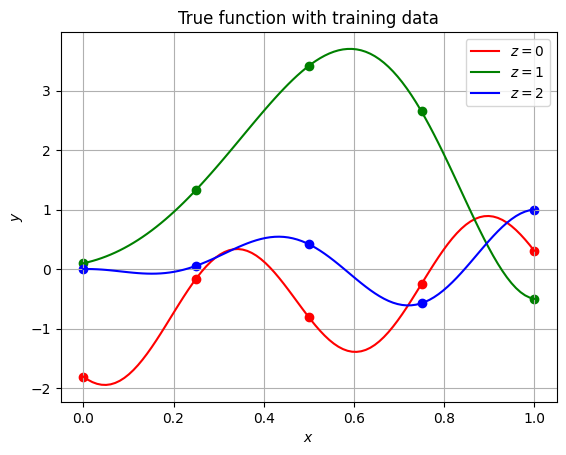

In [9]:
fig, ax = plt.subplots()

c = ["r", "g", "b"]

ax.grid()

for z in [0,1,2]:
    mask = xplot[:,1] == z
    x_tmp = xplot[mask,0]

    ax.plot(x_tmp.numpy(force=True), yplot[mask,0].numpy(force=True), f"{c[z]}-", label=f"$z={z}$")

    mask = xtrain[:,1] == z
    x_tmp = xtrain[mask,0]

    ax.scatter(x_tmp.numpy(force=True), ytrain[mask,0].numpy(force=True), c=f"{c[z]}")

ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("True function with training data")

## Define NN model

We will use `FeedForwardNeuralNetwork` class from `scimlstudio` package for creating a fully-connected neural network. This class can be used to create any sort of feed-forward model, such as multi-layer perceptron and convolutional neural network, for a supervised learning task.

The `FeedForwardNeuralNetwork` class take following arguments during initialization:

- `x_train`: a 2D torch tensor representing input training data
- `y_train`: a 2D torch tensor representing the output data
- `network`: an instance of `Sequential` class defining the neural network model architecture
- `input_transform`: an instance of `Normalize` or `Standardize` class used for input scaling, default = None
- `output_transform`: an instance of `Normalize` or `Standardize` class used for output scaling, default = None

First, let's define network architecture using the [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) class. To initialize this class, you need to pass instances of various modules in the order you want to process the data. Here, module refers to various classes provides by torch package for performing computation on the data. Let's define a simple network to illustrate how this class works. The network will consist of two hidden layers with SiLU activation function, where each layers consists of 32 neurons. Below code block defines this network:

In [47]:
network = torch.nn.Sequential(
    torch.nn.Linear(xtrain.shape[1], 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 1),
).to(**args)

Notice how the class is initialized. It uses two different modules - `Linear` and `SiLU`. The [`Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) module primarily takes arguments - input size and output size. Essentially, `Linear` module takes data $\mathbf{x}$ and performs a linear transformation:

$$
    \mathbf{z} = W\mathbf{x} + \mathbf{b},
$$

where $W$ is the weight matrix (size is based on output and input size) and $b$ is the bias. The `SiLU` modules your activation function. It takes given input data and applies a nonlinear function elementwise. [Check](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) the list of various activation functions available in PyTorch.

In [ ]:
input_transform = Standardize(xtrain)
output_transform = Standardize(ytrain)

# initialize the model class
model = FeedForwardNeuralNetwork(xtrain, ytrain, network, input_transform, output_transform)

## Train NN model

In [49]:
optimizer = torch.optim.Adam(model.parameters, lr=0.01)

loss_func = torch.nn.MSELoss()

batch_size = xtrain.shape[0]

epochs = 500

model.fit(optimizer, loss_func, batch_size,epochs)

## Predict

In [50]:
yplot_pred = model.predict(xplot)

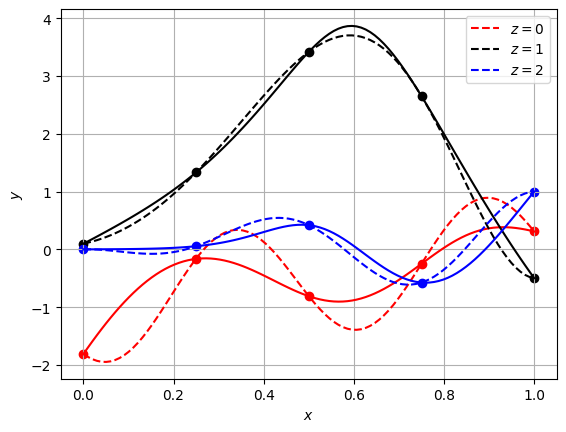

In [51]:
fig, ax = plt.subplots()

c = ["r", "k", "b"]

for z in [0,1,2]:

    mask = xplot[:,1] == z
    x_tmp = xplot[mask,0]

    ax.plot(x_tmp.numpy(force=True), yplot[mask,0].numpy(force=True), f"{c[z]}--", label=f"$z={z}$")

    ax.plot(x_tmp.numpy(force=True), yplot_pred[mask,0].numpy(force=True), f"{c[z]}-")

    mask = xtrain[:,1] == z
    x_tmp = xtrain[mask,0]

    ax.scatter(x_tmp.numpy(force=True), ytrain[mask,0].numpy(force=True), c=f"{c[z]}")

ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid()

## Parity plots